In [2]:

import nibabel as nib
import numpy as np
!pip install scipy
import os
import json
from scipy import ndimage
!pip install vtk
import vtkmodules.all as vtk
from vtkmodules.util import numpy_support
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion, binary_dilation
from skimage.morphology import skeletonize
from scipy.interpolate import splprep, splev
from scipy.spatial import cKDTree


In [3]:
def numpy_to_vtk_image(arr, affine):
    arr_c = np.ascontiguousarray(arr, dtype=np.float32)
    vtk_arr = numpy_support.numpy_to_vtk(arr_c.ravel(order='F'))
    image = vtk.vtkImageData()
    image.SetDimensions(arr.shape)
    spacing = np.sqrt((affine[:3, :3] ** 2).sum(axis=0))
    image.SetSpacing(*spacing)
    image.GetPointData().SetScalars(vtk_arr)
    return image


def render_surface(vtk_image, iso_value=0.5, color=(0.0, 0.8, 1.0), title="Mask"):
    # Marching cubes isosurface
    mc = vtk.vtkMarchingCubes()
    mc.SetInputData(vtk_image)
    mc.SetValue(0, iso_value)
    mc.Update()

    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputConnection(mc.GetOutputPort())
    mapper.ScalarVisibilityOff()

    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    actor.GetProperty().SetColor(*color)
    actor.GetProperty().SetOpacity(0.85)

    renderer = vtk.vtkRenderer()
    renderer.AddActor(actor)
    renderer.SetBackground(0.05, 0.07, 0.1)
    renderer.ResetCamera()

    window = vtk.vtkRenderWindow()
    window.SetWindowName(title)
    window.SetSize(900, 700)
    window.AddRenderer(renderer)

    interactor = vtk.vtkRenderWindowInteractor()
    interactor.SetRenderWindow(window)
    interactor.SetInteractorStyle(vtk.vtkInteractorStyleTrackballCamera())

    window.Render()
    interactor.Start()

In [4]:

#visualize
def visualize(img):
    for i in range(img.shape[0]):
        if(np.sum(np.array(img[:,:,i])) > 0.0):
            plt.imshow(img[:, :, i], cmap='gray')
            plt.show()
            
#visualize(nii_data)
#Open/Close 3D mask
def create_spherical_mask(r):
    size = 2 * r + 1
    center = r

    z = np.arange(size)
    y = np.arange(size)
    x = np.arange(size)
    zz, yy, xx = np.meshgrid(z, y, x, indexing='ij')

    dist_sq = (zz - center)**2 + (yy - center)**2 + (xx - center)**2

    return dist_sq <= r**2


In [5]:
#render_surface(numpy_to_vtk_image(skeletonized))

In [6]:
def find_furthest_points(mask, affine=None, subsample=5000):
    """
    Find the two points furthest apart in a binary mask.
    
    Parameters
    ----------
    mask    : ndarray, binary 3D mask
    affine  : 4x4 affine from nibabel (uses mm space if provided, voxels otherwise)
    subsample : max number of voxel candidates to consider (for speed)
    
    Returns
    -------
    p1, p2  : (3,) arrays of coordinates (mm if affine given, else voxel indices)
    dist    : scalar distance between them
    """
    coords = np.argwhere(mask > 0.5)  # (N, 3) voxel indices

    if len(coords) < 2:
        raise ValueError("Mask has fewer than 2 active voxels.")

    # Convert to mm space if affine provided
    if affine is not None:
        coords_mm = nib.affines.apply_affine(affine, coords)
    else:
        coords_mm = coords.astype(float)

    # Subsample if too large (exact O(N²) is slow for big masks)
    if len(coords_mm) > subsample:
        idx = np.random.choice(len(coords_mm), subsample, replace=False)
        coords_mm = coords_mm[idx]

    # Two-pass approximation: pick a random seed, find furthest point A,
    # then find furthest point B from A. Gives exact answer for convex shapes.
    seed = coords_mm[0]
    dists_from_seed = np.linalg.norm(coords_mm - seed, axis=1)
    a_idx = np.argmax(dists_from_seed)

    dists_from_a = np.linalg.norm(coords_mm - coords_mm[a_idx], axis=1)
    b_idx = np.argmax(dists_from_a)

    p1 = coords_mm[a_idx]
    p2 = coords_mm[b_idx]
    dist = dists_from_a[b_idx]

    return p1, p2, dist

In [7]:
def find_closest_point(mask, query_point, affine=None):
    """
    Find the closest point in a mask to a given query point.

    Parameters
    ----------
    mask        : ndarray, binary 3D mask
    query_point : (3,) array, coordinate to query (mm if affine given, else voxel)
    affine      : 4x4 affine from nibabel (uses mm space if provided, voxels otherwise)

    Returns
    -------
    closest     : (3,) array, closest mask point (mm or voxel, matching query space)
    dist        : scalar distance to that point
    """
    coords = np.argwhere(mask > 0.5)

    if len(coords) == 0:
        raise ValueError("Mask has no active voxels.")

    if affine is not None:
        coords_mm = nib.affines.apply_affine(affine, coords)
    else:
        coords_mm = coords.astype(float)

    query_point = np.asarray(query_point, dtype=float)
    dists = np.linalg.norm(coords_mm - query_point, axis=1)
    idx = np.argmin(dists)

    return coords_mm[idx], dists[idx]




In [8]:
#p1, p2, dist = find_furthest_points(skeletonized)

In [9]:
#print(dist)

In [10]:
def distance(p1, p2):
    p1, p2 = np.asarray(p1), np.asarray(p2)
    return np.linalg.norm(p1 - p2)


In [11]:
def zero_mask_at(mask, p, affine=None):
    """
    Set mask to 0 at point p.

    Parameters
    ----------
    mask   : ndarray, 3D mask (modified in place)
    p      : (3,) coordinate (mm if affine given, else voxel indices)
    affine : 4x4 affine from nibabel
    """
    if affine is not None:
        vox = np.linalg.inv(affine) @ np.append(p, 1)
        vox = np.round(vox[:3]).astype(int)
    else:
        vox = np.round(p).astype(int)

    mask[vox[0], vox[1], vox[2]] = 0.0

In [12]:
#print(dist)

In [13]:


def fit_spline_and_length(points, n_anchor=10, n_eval=1000):
    """
    Fit a spline anchored every n points, return the spline and its arc length.

    Parameters
    ----------
    points   : (N, 3) array of ordered 3D points
    n_anchor : use every nth point as a knot anchor
    n_eval   : number of points to evaluate along spline for length integration

    Returns
    -------
    length   : arc length of the spline
    tck, u   : spline representation (for further evaluation/plotting)
    """
    points = np.asarray(points)
    anchors = points[::n_anchor]

    # Ensure last point is always included
    if not np.allclose(anchors[-1], points[-1]):
        anchors = np.vstack([anchors, points[-1]])

    tck, u = splprep(anchors.T, s=0, k=min(3, len(anchors) - 1))

    # Evaluate at fine resolution and integrate arc length
    t_fine = np.linspace(0, 1, n_eval)
    dx, dy, dz = splev(t_fine, tck, der=1)
    dt = t_fine[1] - t_fine[0]
    length = np.sum(np.sqrt(dx**2 + dy**2 + dz**2)) * dt

    return length, tck, u

In [14]:
def mse_mask_spline(mask, tck, affine=None, n_eval=1000):
    """
    MSE between each mask voxel and its closest point on the spline.
    """
    coords = np.argwhere(mask > 0.5).astype(float)
    if affine is not None:
        coords = nib.affines.apply_affine(affine, coords)

    t_fine = np.linspace(0, 1, n_eval)
    x, y, z = splev(t_fine, tck)
    spline_pts = np.column_stack([x, y, z])

    tree = cKDTree(spline_pts)
    dists, _ = tree.query(coords)

    return np.mean(dists ** 2)

In [15]:
#print(true_i)

In [16]:
def visualize_mask_and_spline(vtk_image, tck, iso_value=0.5, n_eval=1000,
                               mask_color=(0.0, 0.8, 1.0), spline_color=(1.0, 0.3, 0.0),
                               spline_radius=0.5):
    # ── Mask surface ──────────────────────────────────
    mc = vtk.vtkMarchingCubes()
    mc.SetInputData(vtk_image)
    mc.SetValue(0, iso_value)
    mc.Update()

    mask_mapper = vtk.vtkPolyDataMapper()
    mask_mapper.SetInputConnection(mc.GetOutputPort())
    mask_mapper.ScalarVisibilityOff()

    mask_actor = vtk.vtkActor()
    mask_actor.SetMapper(mask_mapper)
    mask_actor.GetProperty().SetColor(*mask_color)
    mask_actor.GetProperty().SetOpacity(0.4)

    # ── Spline tube ───────────────────────────────────
    t_fine = np.linspace(0, 1, n_eval)
    x, y, z = splev(t_fine, tck)

    pts = vtk.vtkPoints()
    lines = vtk.vtkCellArray()
    lines.InsertNextCell(n_eval)
    for i, (xi, yi, zi) in enumerate(zip(x, y, z)):
        pts.InsertPoint(i, xi, yi, zi)
        lines.InsertCellPoint(i)

    spline_pd = vtk.vtkPolyData()
    spline_pd.SetPoints(pts)
    spline_pd.SetLines(lines)

    tube = vtk.vtkTubeFilter()
    tube.SetInputData(spline_pd)
    tube.SetRadius(spline_radius)
    tube.SetNumberOfSides(20)
    tube.Update()

    spline_mapper = vtk.vtkPolyDataMapper()
    spline_mapper.SetInputConnection(tube.GetOutputPort())

    spline_actor = vtk.vtkActor()
    spline_actor.SetMapper(spline_mapper)
    spline_actor.GetProperty().SetColor(*spline_color)
    spline_actor.GetProperty().SetOpacity(0.5)

    # ── Render ────────────────────────────────────────
    renderer = vtk.vtkRenderer()
    renderer.AddActor(mask_actor)
    renderer.AddActor(spline_actor)
    renderer.SetBackground(0.05, 0.07, 0.1)
    renderer.ResetCamera()

    window = vtk.vtkRenderWindow()
    window.SetWindowName("Mask + Spline")
    window.SetSize(900, 700)
    window.AddRenderer(renderer)

    interactor = vtk.vtkRenderWindowInteractor()
    interactor.SetRenderWindow(window)
    interactor.SetInteractorStyle(vtk.vtkInteractorStyleTrackballCamera())

    window.Render()
    interactor.Start()

In [17]:
def visualize_two_masks(vtk_image1, vtk_image2, iso_value=0.5,
                        color1=(0.0, 0.8, 1.0), color2=(1.0, 0.3, 0.0),
                        opacity1=0.4, opacity2=0.4):

    def make_actor(vtk_image, color, opacity):
        mc = vtk.vtkMarchingCubes()
        mc.SetInputData(vtk_image)
        mc.SetValue(0, iso_value)
        mc.Update()
        mapper = vtk.vtkPolyDataMapper()
        mapper.SetInputConnection(mc.GetOutputPort())
        mapper.ScalarVisibilityOff()
        actor = vtk.vtkActor()
        actor.SetMapper(mapper)
        actor.GetProperty().SetColor(*color)
        actor.GetProperty().SetOpacity(opacity)
        return actor

    renderer = vtk.vtkRenderer()
    renderer.AddActor(make_actor(vtk_image1, color1, opacity1))
    renderer.AddActor(make_actor(vtk_image2, color2, opacity2))
    renderer.SetBackground(0.05, 0.07, 0.1)
    renderer.ResetCamera()

    window = vtk.vtkRenderWindow()
    window.SetWindowName("Mask Comparison")
    window.SetSize(900, 700)
    window.AddRenderer(renderer)

    interactor = vtk.vtkRenderWindowInteractor()
    interactor.SetRenderWindow(window)
    interactor.SetInteractorStyle(vtk.vtkInteractorStyleTrackballCamera())

    window.Render()
    interactor.Start()



In [18]:
def visualize_two_masks(vtk_image1, vtk_image2, tcks=[], iso_value=0.5,
                        color1=(0.0, 0.8, 1.0), color2=(1.0, 0.3, 0.0),
                        opacity1=0.4, opacity2=0.4, spline_radius=0.5, n_eval=1000):

    def make_mask_actor(vtk_image, color, opacity):
        mc = vtk.vtkMarchingCubes()
        mc.SetInputData(vtk_image)
        mc.SetValue(0, iso_value)
        mc.Update()
        mapper = vtk.vtkPolyDataMapper()
        mapper.SetInputConnection(mc.GetOutputPort())
        mapper.ScalarVisibilityOff()
        actor = vtk.vtkActor()
        actor.SetMapper(mapper)
        actor.GetProperty().SetColor(*color)
        actor.GetProperty().SetOpacity(opacity)
        return actor

    def make_spline_actor(tck, color, opacity=0.4):
        t_fine = np.linspace(0, 1, n_eval)
        x, y, z = splev(t_fine, tck)
        pts = vtk.vtkPoints()
        lines = vtk.vtkCellArray()
        lines.InsertNextCell(n_eval)
        for i, (xi, yi, zi) in enumerate(zip(x, y, z)):
            pts.InsertPoint(i, xi, yi, zi)
            lines.InsertCellPoint(i)
        pd = vtk.vtkPolyData()
        pd.SetPoints(pts)
        pd.SetLines(lines)
        tube = vtk.vtkTubeFilter()
        tube.SetInputData(pd)
        tube.SetRadius(spline_radius)
        tube.SetNumberOfSides(20)
        tube.Update()
        mapper = vtk.vtkPolyDataMapper()
        mapper.SetInputConnection(tube.GetOutputPort())
        actor = vtk.vtkActor()
        actor.SetMapper(mapper)
        actor.GetProperty().SetColor(*color)
        actor.GetProperty().SetOpacity(opacity)
        return actor

    spline_colors = [
        (1.0, 0.3, 0.0), (0.0, 1.0, 0.4), (1.0, 1.0, 0.0),
        (1.0, 0.0, 0.8), (0.5, 0.8, 1.0), (1.0, 0.6, 0.0),
    ]

    renderer = vtk.vtkRenderer()
    renderer.AddActor(make_mask_actor(vtk_image1, color1, opacity1))
    renderer.AddActor(make_mask_actor(vtk_image2, color2, opacity2))
    for i, tck in enumerate(tcks):
        renderer.AddActor(make_spline_actor(tck, spline_colors[i % len(spline_colors)]))
    renderer.SetBackground(0.05, 0.07, 0.1)
    renderer.ResetCamera()

    window = vtk.vtkRenderWindow()
    window.SetWindowName("Mask Comparison")
    window.SetSize(900, 700)
    window.AddRenderer(renderer)

    interactor = vtk.vtkRenderWindowInteractor()
    interactor.SetRenderWindow(window)
    interactor.SetInteractorStyle(vtk.vtkInteractorStyleTrackballCamera())

    window.Render()
    interactor.Start()

In [19]:
def get_error(patient_dir, visualize=False):
    
    subject_id = os.path.basename(patient_dir)
    file = os.path.join(patient_dir, f"{subject_id}_catheter.nii.gz")
    #Load 3D catheter mask
    nii_img  = nib.load(file)
    nii_data = nii_img.get_fdata()
    affine = nii_img.affine
    
    mask = create_spherical_mask(7)
    
    #dilated = binary_dilation(nii_data, mask)
    
    #Thin 3D mask
    skeletonized = skeletonize(nii_data)
    
    #Measure 3D mask
    p1_0, p2_0, dist_0 = find_furthest_points(nii_data)
    p1, p2, dist = find_furthest_points(skeletonized)
    mask = skeletonized.copy()
    point_list = []
    p= p1.copy()
    point_list = [p1_0, p]
    dist = 0
    while not np.allclose(p, p2):
        zero_mask_at(mask,p)
        p3, d= find_closest_point(mask, p)
        dist+=d
        p = p3
        point_list.append(p)
    point_list.append(p2_0) 
    mse = np.inf
    best_length = 0
    tck_list = []
    for i in range(1,10):
        length, tck, u = fit_spline_and_length(point_list, n_anchor=i)
        tck_list.append(tck)
        new_mse = mse_mask_spline(nii_data, tck)
        if(new_mse < mse):
            true_tck = tck
            best_length = length
            true_i = i
    
    if(visualize):
        #visualize_two_masks(numpy_to_vtk_image(nii_data, affine), numpy_to_vtk_image(skeletonized, affine), tck_list)
        visualize_mask_and_spline(numpy_to_vtk_image(nii_data, affine), true_tck)
        
    with open(os.path.join(patient_dir, f"{subject_id}.json")) as f:
        true_length = json.load(f)["catheter_length_mm"]

    return best_length - true_length


In [ ]:

errors = []
subjects = []
bigger_dir = "./MIA_DATA/PROJ2_Subjects"
num_image = 0
for subject in sorted(os.listdir(bigger_dir)):
    print(f"{num_image} done")
    num_image = num_image + 1
    patient_dir = os.path.join(bigger_dir, subject)
    if os.path.isdir(patient_dir):
        errors.append(get_error(patient_dir))
        
        
print(np.average(errors))

worst_idx = np.argmax(np.abs(errors))
print(f"Worst subject: {subjects[worst_idx]} | Error: {errors[worst_idx]:.2f} mm")
get_error(subjects[worst_idx], visualize=True)

0 done
1 done
2 done
3 done
4 done
5 done
6 done
7 done
8 done
9 done
10 done
11 done
12 done
13 done
14 done
15 done
16 done
17 done
18 done
19 done
20 done
21 done
22 done
23 done
24 done
25 done
26 done
27 done
28 done
29 done
30 done
31 done
32 done
33 done
34 done
35 done
36 done
37 done
38 done
39 done
40 done
41 done
42 done
43 done
44 done
45 done
46 done
47 done
48 done
49 done
50 done
51 done
52 done
53 done
54 done
55 done
56 done
57 done
58 done
59 done
60 done
61 done
62 done
63 done
64 done
65 done
66 done
67 done
68 done
69 done
70 done
71 done
72 done
73 done
74 done
75 done
76 done
77 done
78 done
79 done
80 done
81 done
82 done
83 done
84 done
85 done
86 done
87 done
88 done
89 done
90 done
91 done
92 done
93 done
94 done
95 done
96 done
97 done
98 done
99 done
100 done
101 done
102 done
103 done
104 done
105 done
106 done
107 done
108 done
109 done
110 done
111 done
112 done
113 done
114 done
115 done
116 done
117 done
118 done
119 done
120 done
121 done
122 done
123

5.02899913286395
Mean Absolute Error: 5.0290


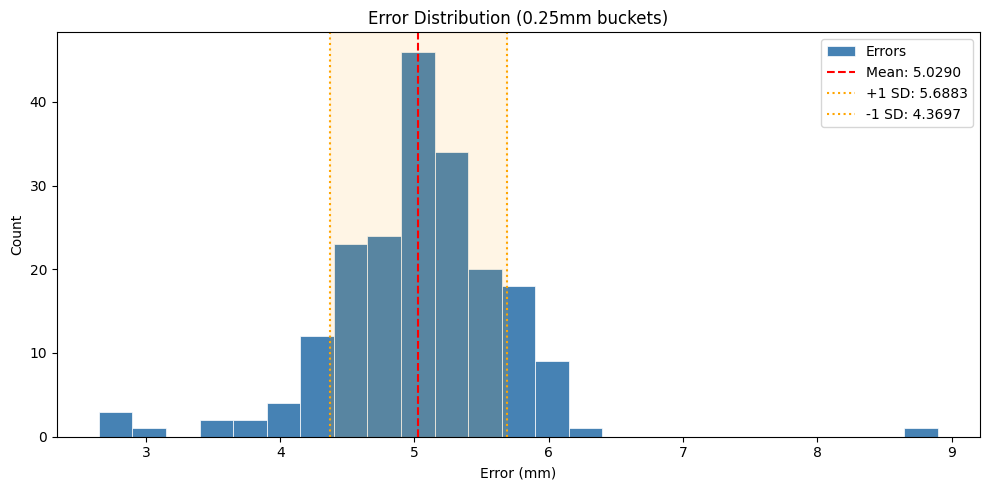

In [22]:
print(np.average(np.abs(errors)))

# --- Stats ---
mae = np.average(np.abs(errors))
mean_err = np.mean(errors)
std_err = np.std(errors)
print(f"Mean Absolute Error: {mae:.4f}")

# --- Plot ---
bucket_size = 0.25
bins = np.arange(min(errors), max(errors) + bucket_size, bucket_size)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(errors, bins=bins, color="steelblue", edgecolor="white", linewidth=0.5, label="Errors")

ax.axvline(mean_err, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_err:.4f}")
ax.axvline(mean_err + std_err, color="orange", linestyle=":", linewidth=1.5, label=f"+1 SD: {mean_err + std_err:.4f}")
ax.axvline(mean_err - std_err, color="orange", linestyle=":", linewidth=1.5, label=f"-1 SD: {mean_err - std_err:.4f}")
ax.axvspan(mean_err - std_err, mean_err + std_err, alpha=0.1, color="orange")

ax.set_title("Error Distribution (0.25mm buckets)")
ax.set_xlabel("Error (mm)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#visualize_two_masks(numpy_to_vtk_image(nii_data), numpy_to_vtk_image(skeletonized), tck_list)

In [ ]:
#visualize_mask_and_spline(numpy_to_vtk_image(nii_data), true_tck)

In [ ]:
#print(true_length)

In [ ]:

errors = []
subjects = []
bigger_dir = "./MIA_DATA/PROJ2_Subjects"
num_image = 0
for subject in sorted(os.listdir(bigger_dir)):
    print(f"{num_image} done")
    num_image = num_image + 1
    patient_dir = os.path.join(bigger_dir, subject)
    if os.path.isdir(patient_dir):
        errors.append(get_error(patient_dir))
        
        subjects.append(patient_dir)
        
        
print(np.average(errors))

worst_idx = np.argmax(np.abs(errors))
print(f"Worst subject: {subjects[worst_idx]} | Error: {errors[worst_idx]:.2f} mm")
get_error(subjects[worst_idx], visualize=True)

0 done
1 done
2 done
3 done
4 done
5 done
6 done
7 done
8 done
9 done
10 done
11 done
12 done
13 done
14 done
15 done
16 done
17 done
18 done
19 done
20 done
21 done
22 done
23 done
24 done
25 done
26 done
27 done
28 done
29 done
30 done
31 done
32 done
33 done
34 done
35 done
36 done
37 done
38 done
39 done
40 done
41 done
42 done
43 done
44 done
45 done
46 done
47 done
48 done
49 done
50 done
51 done
52 done
53 done
54 done
55 done
56 done
57 done
58 done
59 done
60 done
61 done
62 done
63 done
64 done
65 done
66 done
67 done
68 done
69 done
70 done
71 done
72 done
73 done
74 done
75 done
76 done
77 done
78 done
79 done
80 done
81 done
82 done
83 done
84 done
85 done
86 done
87 done
88 done
89 done
90 done
91 done
92 done
93 done
94 done
95 done
96 done
97 done
98 done
99 done
100 done
101 done
102 done
103 done
104 done
105 done
106 done
107 done
108 done
109 done
110 done
111 done
112 done
113 done
114 done
115 done
116 done
117 done
118 done
119 done
120 done
121 done
122 done
123

ValueError: attempt to get argmax of an empty sequence

In [25]:
print(worst_idx)

47
